In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
df = pd.read_csv("Churn_Table.csv")

In [3]:
# First 5 rows
print(df.head())

# Dataset shape
print(df.shape)

# Column info
print(df.info())

# Missing values
print(df.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingTV  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...          No   
4                No     Fiber optic             No  ...          No   

  StreamingMovies        Contract PaperlessBilling              PaymentMethod  \
0          

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_5100\981826092.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [6]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

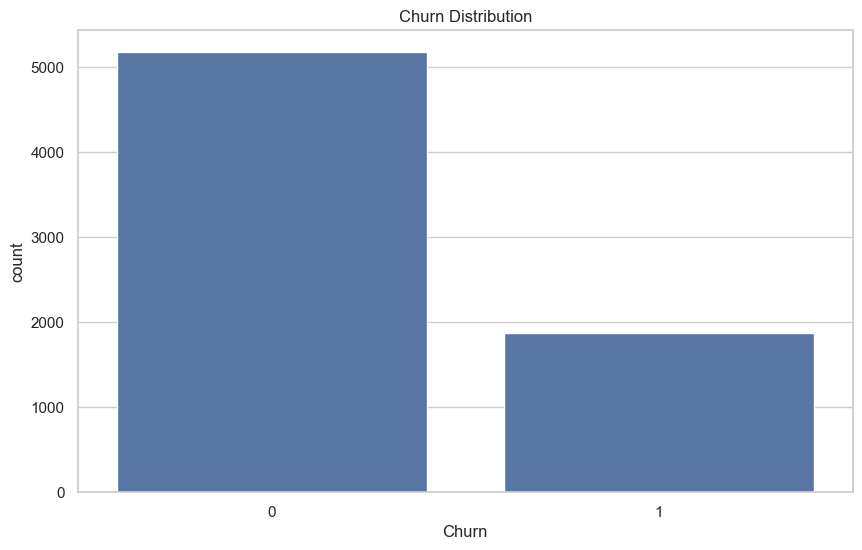

In [7]:
sns.countplot(x="Churn", data=df)

plt.title("Churn Distribution")
plt.show()

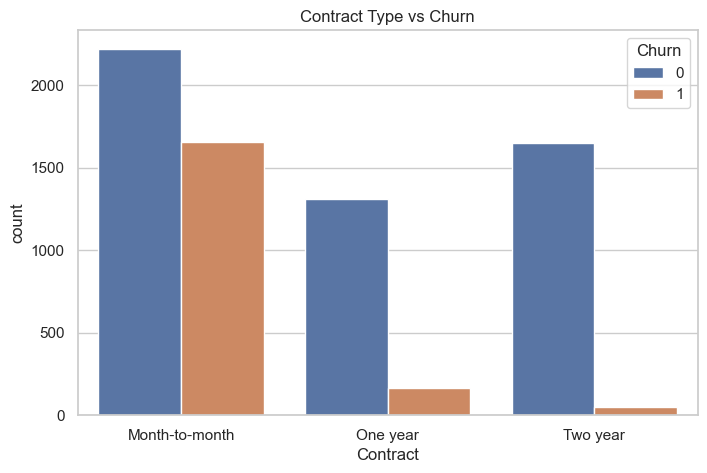

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")
plt.show()

In [9]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


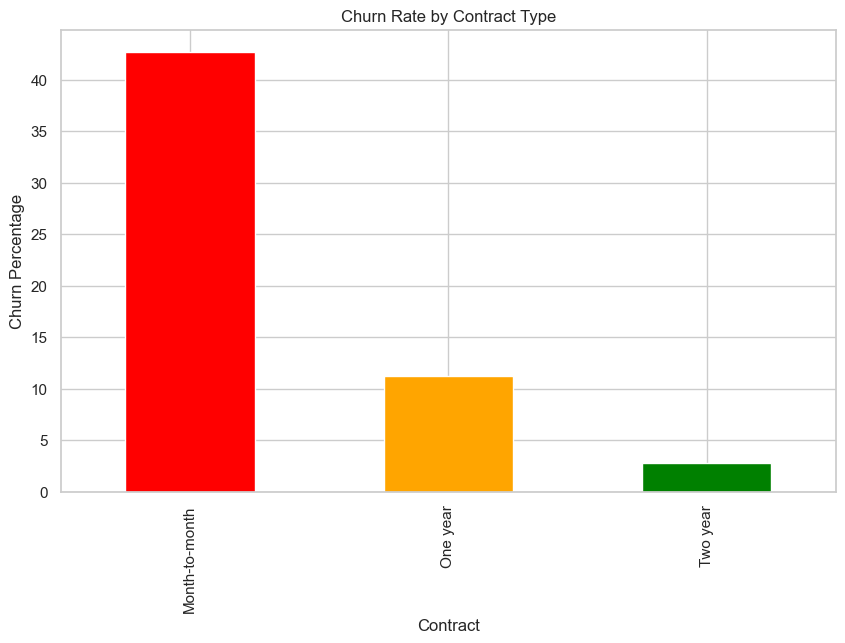

In [10]:
contract_churn.plot(
    kind="bar",
    color=["red","orange","green"]
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Contract Type")
plt.show()

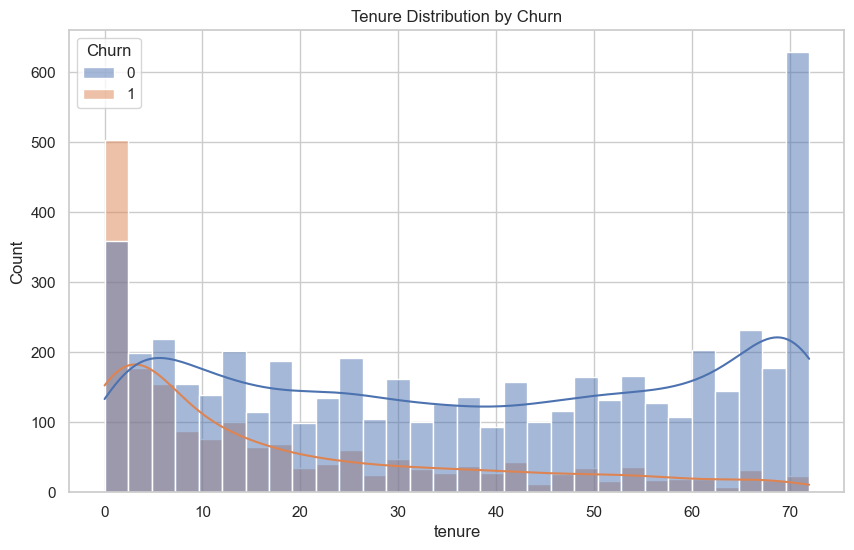

In [11]:
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.show()

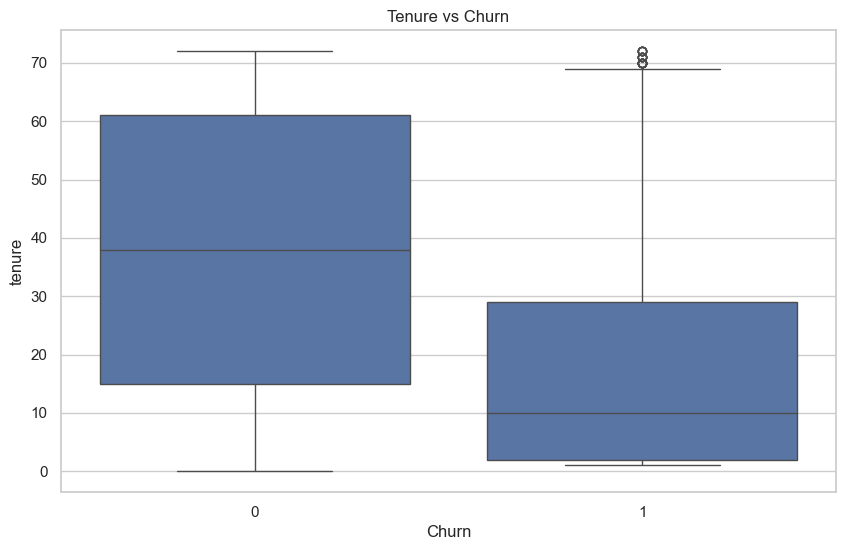

In [12]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

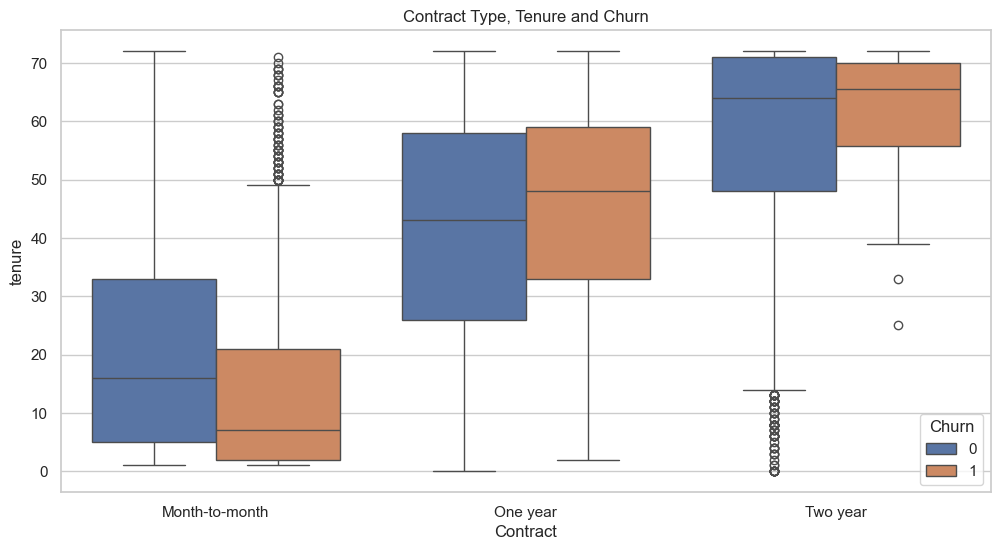

In [13]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Contract",
    y="tenure",
    hue="Churn",
    data=df
)

plt.title("Contract Type, Tenure and Churn")
plt.show()

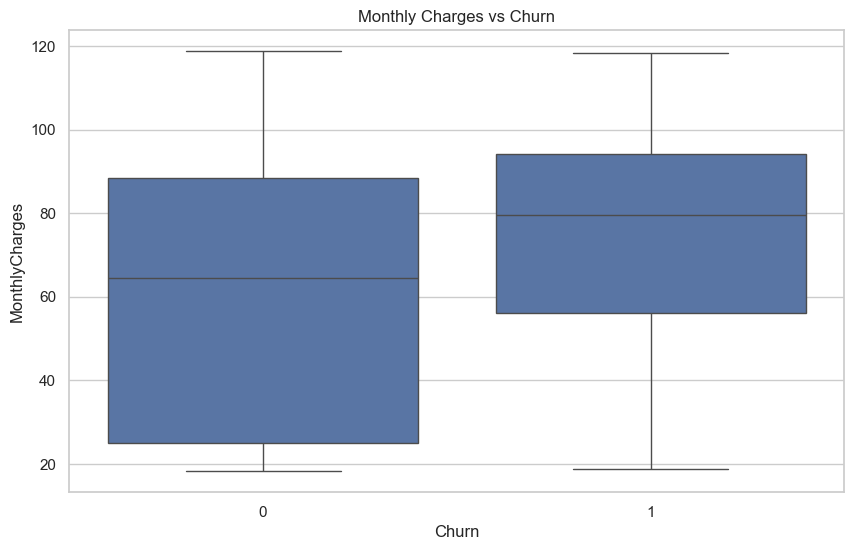

In [14]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()